#### Import numpy & keras

In [15]:
import numpy as np
import keras
from datasets import load_dataset, DatasetDict, Image
import datetime

In [16]:
import tensorflow as tf
print(tf.__version__)
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.config.list_physical_devices('GPU'))

2.21.0
Num GPUs Available:  0
[]


### Bilder normalisieren

In [17]:
def transform(example):
    image = np.array(example["image"], dtype=np.float32) / 255.0
    return {"image": image, "label": example["label"]}


#### 1. get training data

In [ ]:
import matplotlib.pyplot as plt
import PIL
print(PIL.__version__)

ds = load_dataset("jonathan-roberts1/NWPU-RESISC45")
print(ds.shape)

train_data = ds["train"]
split_1 = train_data.train_test_split(
    test_size=0.15,
    seed=42,          # sorgt dafür, dass Validation immer gleich bleibt
    shuffle=True
)

validation_dataset = split_1["test"]
remaining_dataset = split_1["train"]

In [18]:
split_2 = remaining_dataset.train_test_split(
    test_size=0.25,
    seed=42,
    shuffle=True
)

train_ds = split_2["train"]
test_ds = split_2["test"]

# DatasetDict erzeugen
final_dataset = DatasetDict({
    "train": train_ds,
    "validation": validation_dataset,
    "test": test_ds
})
final_dataset = final_dataset.cast_column("image", Image())
final_dataset.with_format("tf")
final_dataset = final_dataset.with_transform(transform)

print(final_dataset)

train_images = (final_dataset["train"]["image"])
test_images = (final_dataset["test"]["image"])

train_labels = (final_dataset["train"]["label"])
test_labels = (final_dataset["test"]["label"])

tf_train = final_dataset["train"].to_tf_dataset(
    columns=["image"],
    label_cols=["label"],
    batch_size=128,
    shuffle=True
)

tf_test = final_dataset["test"].to_tf_dataset(
    columns=["image"],
    label_cols=["label"],
    batch_size=128
)

class_names = final_dataset["train"].features["label"].names
print(class_names)

img_shape = np.array(final_dataset["train"][0]["image"]).shape
print(img_shape)

12.2.0
{'train': (31500, 2)}
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 20081
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 4725
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 6694
    })
})
['airplane', 'airport', 'baseball diamond', 'basketball court', 'beach', 'bridge', 'chaparral', 'church', 'circular farmland', 'cloud', 'commercial area', 'dense residential', 'desert', 'forest', 'freeway', 'golf course', 'ground track field', 'harbor', 'industrial area', 'intersection', 'island', 'lake', 'meadow', 'medium residential', 'mobile home park', 'mountain', 'overpass', 'palace', 'parking lot', 'railway', 'railway station', 'rectangular farmland', 'river', 'roundabout', 'runway', 'sea ice', 'ship', 'snowberg', 'sparse residential', 'stadium', 'storage tank', 'tennis court', 'terrace', 'thermal power station', 'wetland']
(256, 256, 3)


#### 2. define architecture

In [19]:
# Import a model from /models/*
from models.example_from_presentation import generateModel
model_name = "example_from_presentation.keras"

load model

In [20]:
model = generateModel(img_shape)
#model = keras.models.load_model("./model/" + model_name)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 500)            │   123,008,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 45)             │        22,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,050,439 (469.40 MB)

 Trainable params: 123,050,437 (469.40 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

#### 3. set training parameter and fit model

In [21]:
model.compile(
    optimizer='sgd',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

log_dir = "logs/" + model_name + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

model.fit(
    tf_train,
    validation_data=tf_test,
    epochs=20,
    callbacks=[tensorboard_callback]
)
model.save("./models/" + model_name)

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.1304 - loss: 3.3235 - val_accuracy: 0.1885 - val_loss: 3.1093
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.1808 - loss: 3.0581 - val_accuracy: 0.2330 - val_loss: 2.8842
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 189s 1s/step - accuracy: 0.2381 - loss: 2.8441 - val_accuracy: 0.2478 - val_loss: 2.7468
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 178s 1s/step - accuracy: 0.2877 - loss: 2.6202 - val_accuracy: 0.3080 - val_loss: 2.5410
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.3327 - loss: 2.4201 - val_accuracy: 0.3234 - val_loss: 2.4425
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.3823 - loss: 2.2341 - val_accuracy: 0.3615 - val_loss: 2.3025
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.4259 - loss: 2.0716 - val_accuracy: 0.3127 - val_loss: 2.4978
Epoch 8/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.4699 - loss: 1.9066 - val_accu

In [2]:
%load_ext tensorboard
%tensorboard --logdir logs/example_from_presentation

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 18404), started 0:01:32 ago. (Use '!kill 18404' to kill it.)

#### 4. predict output 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
Predicted: desert
True: desert


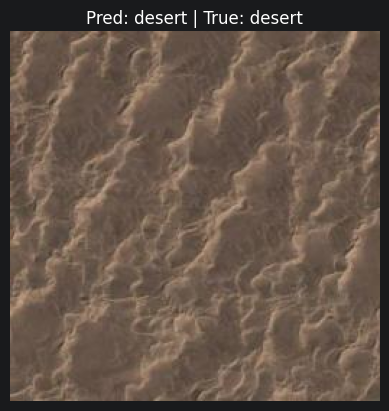

In [23]:
prediction = model.predict(test_images[:1])

predicted_idx = np.argmax(prediction)

true_idx = test_labels[0]

print("Predicted:", class_names[predicted_idx])
print("True:", class_names[true_idx])

# Bild anzeigen
img = test_images[0]

plt.imshow(img)
plt.title(f"Pred: {class_names[predicted_idx]} | True: {class_names[true_idx]}")
plt.axis("off")
plt.show()